## Notes:

<span style="color:red">Red text indicates comments.</span>

<span style="color:green">Green indicates text that has been added.</span>

<s>Strikethroughs</s> indicate text that should be removed.

<span style="color:red">Note that CanSWE v6 is now available. Let's switch to using the newest version in this tutorial.</span>

------------------------

<s># Snow Water Equivalent (SWE) Example</s>
# Exploring the CanSWE dataset with Python

CanSWE is a dataset that includes Pan-Canadian observations of Snow Water Equivalent (SWE). The data is collected by national, provicial and territorial agencies as well as academic institutions, hydropower companies and their partners. 
<span style="color:red">
    Let's add a bit more detail here. 
</span>

<br> <br> For more information or to view the dataset, please refer to: https://zenodo.org/records/7734616. <br> <br>

<span style="color:red">
    Here briefly state the goal of the tutorial. Let's also move the explanation of columns under the code block in the "Exploration" section.
</span>

<s>#### Brief Explanation of Key Columns</s>
<s>In this dataset, we are primarily interested in</s> <span style="color:green"> Looking at the first few lines of data above and scrolling across the columns, we can see that the file contains point observations of </span> snow water equivalent ($kg/m^2$), snow depth (m), and snowpack bulk density ($kg/m^3$). <s>Some other key columns include</s> <span style="color:green">The first several columns contain information about where and when the observations were collected by providing </span> the station identification code, station name, station elevation, station latitude/longitude, and <span style="color:green"> the dates and times when the observations were made </span>. The quality control flags are outlined in the 4 rightmost columns of this SWE dataset. The quality control flags indicate ... <span style="color:red"> add info about what the different quality control flag columns indicate. Let's also add definitions of SWE, snow depth and snowpack bulk density.</span>

## Requirements
First, we import all necessary Python libraries. Some of these are standard Python libraries, while others are third-party libraries that must first be installed in your Python environment.

In [2]:
# Data libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.colors as mcolors
from matplotlib import cm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf

<s>## Exploration</s> 
## Viewing the raw data

<span style="color:green"> The CanSWE database is available in both csv and netCDF formats. In this tutorial, we will work with the csv format file.</span> To begin, we will read the CanSWE dataset into a pandas dataframe using the `read_csv()` function. 

<span style="color:green"> The CanSWE csv file is large and contains a variety of data, so we will need to pass two arguments to the `read_csv()` to instruct pandas on how to interpret the data. First, we set the `low_memory` argument to `False`. This will prompt pandas to read the whole file into memory at once, rather than reading the data in chunks, which should prevent pandas from assigning inconsistent data types in a given column. Next, given that some columns in the csv file are numeric and others are strings, we explicitly assign the data type, or `dtype` of each column. </span><s>We set the 'low_memory' argument to false because we don't want to process the csv file in chunks as it may cause some mixed type inferences. Furthermore, we include the 'dtype' argument to specify a data type to each column so we can get all the data in the proper format and avoid unexpected behaviours.</s> Once this step is completed, we will display the first 6 rows of the data using the head(n) command where n is an integer representing the first 'n' number of rows that should be printed.

In [3]:
import datetime # move this import up to the Requirements code box

# do we need to include dtype if low_memory = False?

df = pd.read_csv(
    'CanSWE-CanEEN_1928-2023_v6.csv', 
    low_memory=False,
    dtype = {
                # the numeric columns in this dataframe should have dtypes of float64 because we
                # want to perserve the precision (the decimal values)
                'a': 'str', 'c': 'Int64', 'd': 'Int64', 'e': 'Int64', 
                'f': 'str', 'g': 'str', 'h': 'str', 'i': 'str', 'j': 'str', 'k': 'str',
                'l': 'Int64', 'm': 'Int64', 'n': 'Int64', 'o': 'Int64',
                'p': 'str', 'q': 'str', 'r': 'str', 's': 'str'
            }
)

df.head(6)

,station_id,time,lat,lon,elevation,source,station_name,station_name_sec,station_name_ter,station_id_sec,station_id_ter,type_mes,snw,snd,den,data_flag_snw,data_flag_snd,qc_flag_snw,qc_flag_snd
0,ALE-05AA805,1965-04-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,688.0,1.76,390.90910,b'',b'',b'',b''
1,ALE-05AA805,1968-03-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,155.0,0.36,430.55554,b'',b'',b'',b''
2,ALE-05AA805,1968-04-03,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,269.0,0.59,455.93220,b'',b'',b'',b''
3,ALE-05AA805,1969-04-01,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,378.0,0.98,385.71430,b'',b'',b'',b''
4,ALE-05AA805,1970-04-02,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,335.0,0.98,341.83673,b'',b'',b'',b''
5,ALE-05AA805,1971-04-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,356.0,0.91,391.20880,b'',b'',b'',b''


<span style="color:red">
    The explanation of columns should be cut and pasted here. Below the explanation, let's add a map showing all the stations included in the dataset.
</span>

<span style="color:green">Next, we can create a map to display the locations of all the stations included in the CanSWE dataset. We will create similar maps below in this tutorial, so we will first create a map function that will allow us to reuse this code.</span> 

<span style="color:red">
    Move mapping function up here.
</span>

In [8]:
# map code

<s>#### Finding a Station With Most Entries
To achieve a good understanding of how snow water equivalent evolves over time, we should search the dataset for a station with the most entries. We can accomplish this by using a linear search algorithm to iterate through the Pandas dataframe to find this station.</s>

<span style="color:red">
    Now that we have found the station with the most entries, let's make note of it, but remove this text block and the code below that was used to find the station. For the purpose of this tutorial we want to focus on the CanSWE data, so we don't need to "show our work" for finding the station with the longest amount of data. Let's save this code somewhere for safe keeping in case we need to reference it in the future.
</span>

In [12]:
stn = ''
maxStn = ''
count = 0
maxCount = 0
i = 0
tempIndex = 0
longitude = 0
latitude = 0
for index, row in df.iterrows():
    if stn == '' and count == 0:
        stn = row['station_id']
        count = count + 1
    elif row['station_id'] == stn:
        count = count + 1
    else:
        if count > maxCount:
            maxCount = count
            maxStn = stn
            i = tempIndex
            longitude = df['lon'][i]
            latitude = df['lat'][i]
        stn = row['station_id']
        count = 1
        tempIndex = index
stn = maxStn
        
print('Station name with the most entries: ' + maxStn)
print('Number of entries: '+ str(maxCount))
print('First appearence of this station ID appears in the dataset at index: '+ str(i))
print('Longitude of the station: '+str(longitude))
print('Latitude of the station: '+str(latitude))

Station name with the most entries: BCE-2G03P
Number of entries: 16749
First appearence of this station ID appears in the dataset at index: 721113
Longitude of the station: -120.7725
Latitude of the station: 49.09414


<span style="color:red">Reworded and moved below...</span>

<s>From the search, the station with the most entries is Station BCE-2G03P. The official name of station BCE-2G03P is Blackwall Peak-Pillow. It is located in British Columbia, and it has a latitude of 49.454445 (degrees North) and a longitude of -123.031944 (degrees East). The elevation there is 1940 meters.</s>


<span style="color:red">
    Move mapping function and it's text box above.
</span>

#### Code For Creating a Contour Plot
Below is a Python function called createContourPlot() that uses the Matplotlib and Cartopy libraries to create a contour plot, which helps us visualize the geographical locations of various stations. <br>
This function takes in a few arguments: The longitude and latitude coordinates of each station, the longitude and the latitude coordinates of a corresponding station ID label, and a list of the station IDs we would like to plot.

In [23]:
# let's avoid "camel case" for function names and change this function to create_map_plot(...)
# when we name variables, functions and classes, we should try to adhere to the Python style guide, where possible: 
# https://peps.python.org/pep-0008/
# https://peps.python.org/pep-0008/#function-and-variable-names

# likewise, we shouldn't use camel case for variables either, camel case is typically reserved for class names

def createContourPlot(x, y, xLabel, yLabel, stnIDs):
    # add a documentation string here to indicate to the user what x, y, xLabel, yLabel and stnIDs are
    
    # add figure width and height as input args to this function
    figure = plt.figure(figsize = (11, 7)) 
    # if we only have one plot, do we need a call to add_subplot here?
    ax = figure.add_subplot(1, 1, 1, projection = ccrs.PlateCarree()) 
    # set extent values should be input args to this function
    ax.set_extent([-135, -110, 46, 59]) #(x0, x1, y0, y1) 
    ax.coastlines()
    # x and y ticks can be computed from the set_extent values
    plt.xticks(range(-135, -109), range(-135, -109), fontsize = 6) # let's do fewer ticks and larger font, try fontsize=8
    plt.yticks(range(46, 60), range(46, 60), fontsize = 6)

    # are these three commented lines needed? Let's remove if not
    #g1 = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels= True, linestyle = '--')
    #g1.xlocator = mticker.FixedLocator([longitude, longitude2, longitude3])
    #g1.ylocator = mticker.FixedLocator([latitude, latitude2, latitude3])
    states_provinces = cfeature.NaturalEarthFeature(
        category ='cultural',
        name ='admin_1_states_provinces_lines',
        scale ='50m', # change to 10m
        facecolor = 'none')

    countries = cfeature.NaturalEarthFeature(
        category = 'cultural',
        name = 'admin_0_boundary_lines_land',
        scale = '50m', # change to 10m
        facecolor = 'none')

    oceans = cfeature.NaturalEarthFeature(
        'physical', 
        'ocean', 
        scale = '50m', # change to 10m
        facecolor = cfeature.COLORS['water'])

    land = cfeature.NaturalEarthFeature(
        'physical', 
        'land', 
        scale = '50m', # change to 10m
        # this is a land feature, but the facecolor is for water...is this facecolor doing anything?
        facecolor = cfeature.COLORS['water']) 

    # let's add a black outline to the markers and let's change their colour to a light red
    ax.plot(x, y, marker = 'o', color='blue', markersize = 5, linestyle='')
    for i in range(0, len(stnIDs)):
        ax.text(xLabel[i], yLabel[i], stnIDs[i], fontsize = 8)
    
    # I would add these add_feature lines underneath the respective feature variable
    
    # should we be passing the `land` variable here instead of cfeature.LAND?
    ax.add_feature(cfeature.LAND, facecolor = 'beige') 
    ax.add_feature(oceans)

    ax.add_feature(states_provinces, linestyle = '--', linewidth = 0.7)
    ax.add_feature(countries, linestyle = '--', linewidth = 0.7)
    
    plt.show()

<span style="color:red">Copied this text from above and reworded slightly...</span>

<s>From the search, the station with the most entries is Station BCE-2G03P. The official name of station BCE-2G03P is Blackwall Peak-Pillow. It is located in British Columbia, and it has a latitude of 49.454445 (degrees North) and a longitude of -123.031944 (degrees East). The elevation there is 1940 meters.</s>

<span style="color:green">Let's take a closer look at station BCE-2G03P (Blackwall Peak-Pillow). This station is located in southern British Columbia. It has a latitude of 49.454445 (degrees North) and a longitude of -123.031944 (degrees East) and the station elevation is 1940 meters. We'll start by plotting the location of this station on a map.</span><s>#### Plotting The Geographical Location of Station BCE-2G03P
From the beginning of this tutorial, we note that longitude/latitude are some of the key columns of this CanSWE dataset. As a result,</s> We can call our createContourPlot() function to plot the location of Station BCE-2G03P.

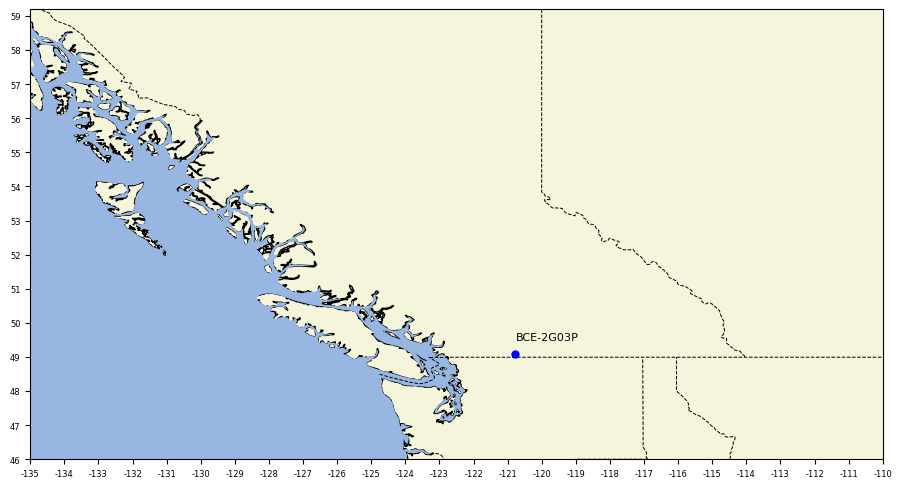

In [10]:
def locations():
    return np.array([[longitude, latitude]]) 
x, y = locations().T
createContourPlot(x, y, x, y + np.repeat(0.4, len(x)), np.repeat(maxStn, len(x)))

# the first time we create a map we get a download warning. We should let the user know to expect this

<s>#### Extracting Data For Station BCE-2G03P into a Separate List</s>

## Visualizing CanSWE data from a single station

After plotting the geographical location of Station BCE-2G03P, the next step is to extract the snow water equivalent, snow depth, and snowpack bulk density data of this station for this station.

In [11]:
from datetime import datetime, timedelta # move these imports up to the Requirements section

# I'm getting an error when I run this code block, where `begin` is a string and `maxCount` is a number

# when we make inline comments, we should include a space between the hash symbol and the first word
#Locating indices to determine where the station BCE-2G03P data is
begin = i
end = begin + maxCount - 1

#Creating a dataframe with just station BCE-2G03P data
reducedDf = df.loc[begin:end]

#Extracting the time periods, snow water equivalent, snow depth and snowpack bulk density into their own lists
snw = reducedDf['snw']
snd = reducedDf['snd']
den = reducedDf['den']
time = []
for i in reducedDf['time']:
   time.append(datetime.strptime(i,'%Y-%m-%d').date())

TypeError: can only concatenate str (not "int") to str

#### Code For Creating a Times Series Graph
Below is a Python function called createTimeSeries() that uses the Matplotlib library to create a time series graph, which helps us visualize trends in snow water equivalent, snow depth and snowpack bulk density. <br>
This function takes in a few arguments: Data for the x-axis (which is normally time in this tutorial), data for the y-axis, a station ID label, a title for the graph, an x-axis label for the graph, a y-axis label for the graph, the lower bound on the x-axis, the upper bound on the x-axis, and a boolean variable isLegend for whether we should display a legend or not.

In [15]:
# see comments above relating to "camel case" and documentation strings

def createTimeSeries(x, y, label, title, xaxis, yaxis, begin, end, isLegend):
    figure, ax = plt.subplots(figsize=(11, 4.8))
    ax.set_title(title)
    ax.set_xlabel(xaxis)
    ax.set_ylabel(yaxis)
    ax.set_xlim(begin, end)
    # with matplotlib we should be able to create a scatter plot without iterating through each data point
    # e.g. https://matplotlib.org/stable/gallery/shapes_and_collections/scatter.html#sphx-glr-gallery-shapes-and-collections-scatter-py
    # matplotlib should also accept pandas series objects, given that we're using pandas for this tutorial,
    # let's plot with pandas series objects instead of numpy arrays
    for i in range(0, len(x)):
        ax.scatter(x[i], y[i], s = 2, label = label[i])
    if (isLegend): # brackets around isLegend are not needed here
        ax.legend()
    plt.show()

#### Plotting The Snow Water Equivalent Data For Station BCE-2G03P
We now use the createTimeSeries() function to plot the snow water equivalent data for this station.

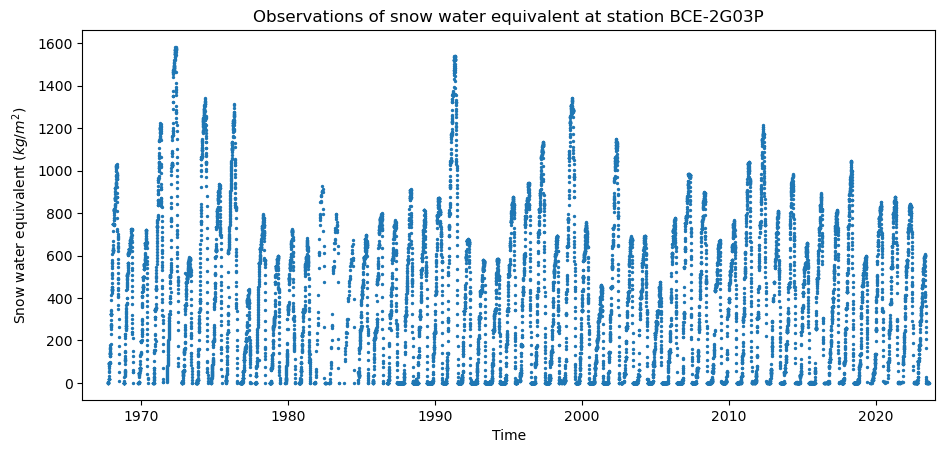

In [19]:
# I made some minor edits to the title, let's change the rest of the plot titles to match
title = 'Observations of snow water equivalent at station '+maxStn 
xaxis = 'Time'
yaxis = 'Snow water equivalent ($kg/m^2$)' # let's change this to (kg m-2) where the -2 is a superscript

createTimeSeries([time], [snw], [maxStn], 
                 title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1), False)

#### Plotting The Snow Depth Data For Station BCE-2G03P
Secondly, we use the createTimeSeries() function to plot the snow depth data for Station BCE-2G03P.

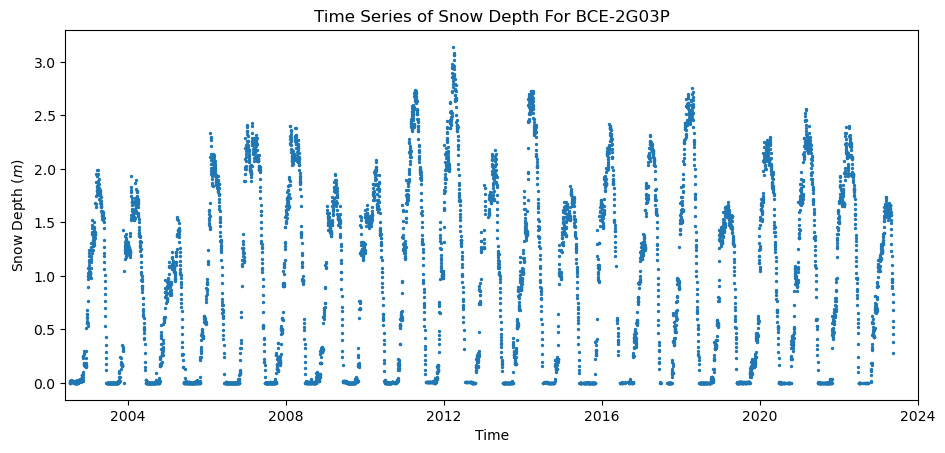

In [20]:
title = 'Time Series of Snow Depth For '+maxStn
xaxis = 'Time'
yaxis = 'Snow Depth ($m$)'
createTimeSeries([time], [snd], [maxStn], 
                 title, xaxis, yaxis, datetime(2002, 6, 1).date(), datetime(2024, 1, 1), False)

#### Plotting The Time Series of Snowpack Bulk Density Data For Station BCE-2G03P
Thirdly, we use the createTimeSeries() function to plot the snowpack bulk density data for Station BCE-2G03P.

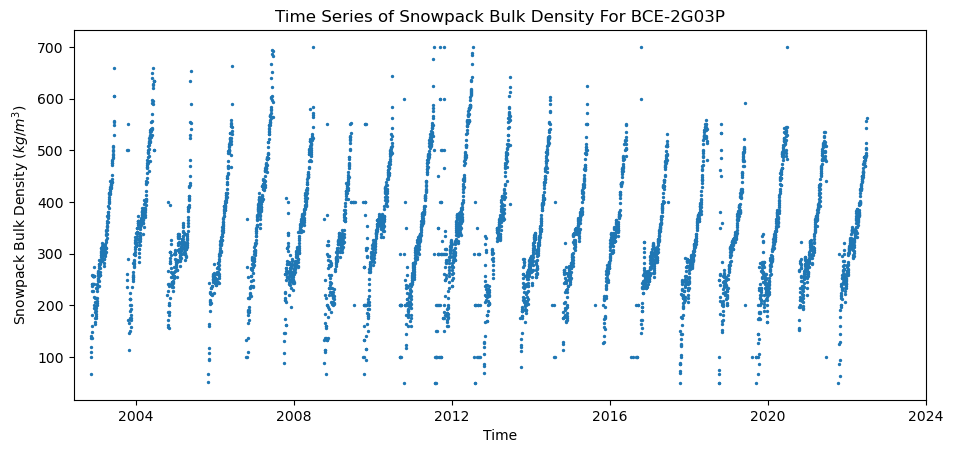

In [10]:
title = 'Time Series of Snowpack Bulk Density For '+maxStn
xaxis = 'Time'
yaxis = 'Snowpack Bulk Density ($kg/m^3$)'
createTimeSeries([time], [den], [maxStn], 
                 title, xaxis, yaxis, datetime(2002, 6, 1).date(), datetime(2024, 1, 1), False)

## Visualizing CanSWE data from multiple locations

#### Finding The Number of Stations in British Columbia

In [24]:
# let's perform this same task using pandas groupby operations, instead of iterating through the dataframe
# with a dataframe this large, iterating through the rows can take time
# we should also use this example to emphasize to the user that they can filter the data in a dataframe to create a
# subset of the data

stnCount = 0
source = 'British Columbia Environment'
currentStn = ''
for index, row in df.iterrows():
    tempSource = row['source']
    tempStn = row['station_id']
    if source == tempSource and currentStn != tempStn:
        stnCount = stnCount + 1
        currentStn = tempStn
        
print('Number of Stations in British Columbia: '+ str(stnCount))

Number of Stations in British Columbia: 531


Among the 525 stations in British Columbia, we have seen the evolution of Snow Water Equivalent, Snow Depth and Snowpack Bulk Density for Station BCE-2G03P. In this next section of the tutorial, we will contninue to work with station BCE-2G03P, but we will also work with 2 nearby stations, which are stations BCE-2F05P and BCE-2F10P.

#### Introducing Stations BCE-2F05P and BCE-2F10P

<span style="color:red">Let's show the user how we can extract the information below from the dataframe directly, i.e. using a pandas .loc operation</span>

The official name of station BCE-2F05P is Mission Creek-Pillow. It has a latitude of 49.94467 (degrees North), a longitude of -118.9497 (degrees East), and an elevation of 1780 meters. <br>
The official name of station BCE-2F10P is Silver Star Mountain. It has a latitude of 50.37136 (degrees North), a longitude of -119.06211 (degrees East), and an elevation of 1840 meters.

#### Plotting The Geographical Location of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Using our createContourPlot() function again, we will plot these 3 stations on one graph to illustrate where they are located and how close they are to one another.

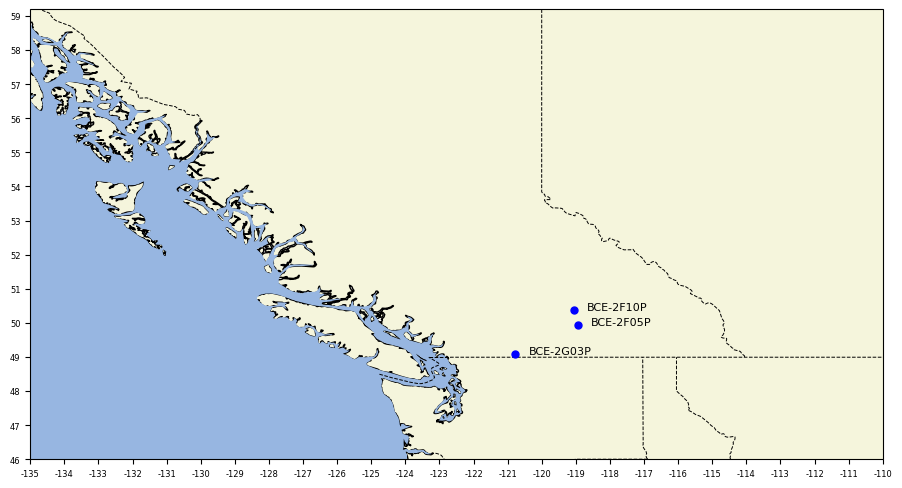

In [12]:
#Station BCE-2F05P
stn2 = 'BCE-2F05P'
latitude2 = 49.94467
longitude2 = -118.9497

#Station BCE-2F10P
stn3 = 'BCE-2F10P'
latitude3 = 50.37136
longitude3 = -119.06211

def locations():
    return np.array([[longitude, latitude], [longitude2, latitude2], [longitude3, latitude3]])

x, y = locations().T
stnIDs = [maxStn, stn2, stn3]
createContourPlot(x, y, x + np.repeat(0.4, len(x)), y, stnIDs)

#### Extracting Data For Stations BCE-2F05P and BCE-2F10P into Separate Lists
In this section of the tutorial, we will compare the data that is found in Stations BCE-2G03P, BCE-2F05P and BCE-2F10P. However, before this comparison, we first need to interate through the SWE Pandas dataframe to find where the data for Stations BCE-2F05P and BCE-2F10P are located. Then, we will extract the snow water equivalence, snow depth, and snowpack bulk density data for these 2 stations.

In [13]:
length = len(time)

#Station BCE-2F05P
#Finding where the Station BCE-2F05P data is
i2 = -1
count2 = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F05P':
        i2 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F05P':
        count2 = count2 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin2 = i2
end2 = begin2 + count2 - 1
reducedDf2 = df.loc[begin2:end2]
snw2 = reducedDf2['snw']
snd2 = reducedDf2['snd']
den2 = reducedDf2['den']

time2 = []
for i in reducedDf2['time']:
   time2.append(datetime.strptime(i,'%Y-%m-%d').date())

#Station BCE-2F10P
#Finding where the Station BCE-2F10P data is
i3 = -1
count3 = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F10P':
        i3 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F10P':
        count3 = count3 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin3 = i3
end3 = begin3 + count3 - 1
reducedDf3 = df.loc[begin3:end3]
snw3 = reducedDf3['snw']
snd3 = reducedDf3['snd']
den3 = reducedDf3['den']

time3 = []
for i in reducedDf3['time']:
   time3.append(datetime.strptime(i,'%Y-%m-%d').date())

#### Plotting The Snow Water Equivalent of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
We use the createTimeSeries() function to plot the SWE data for Stations BCE-2G03P, BCE-2F05P and BCE-2F10P.
<span style="color:red">In the plot below we should keep the data from the BCE-2G03P station the colour blue so that it's consistent with the plots above.</span>

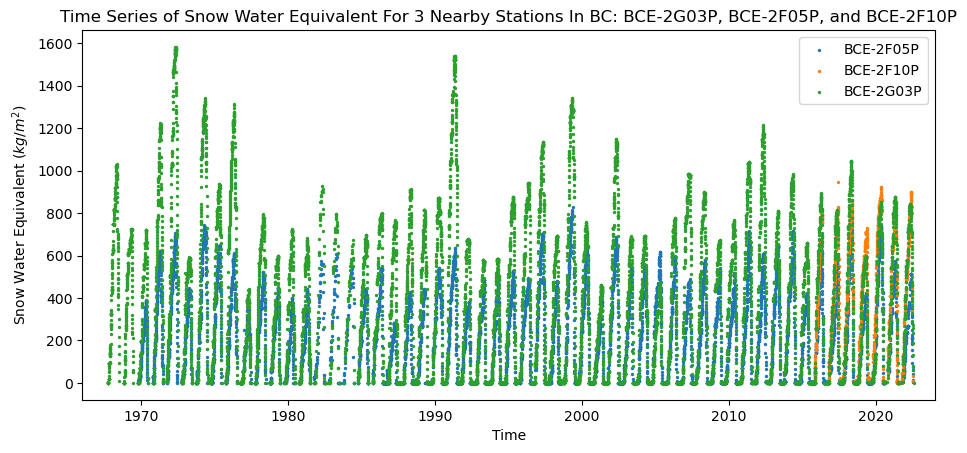

In [14]:
title = 'Time Series of Snow Water Equivalent For 3 Nearby Stations In BC: '+maxStn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time2, time3, time], 
                 [snw2, snw3, snw], 
                 [stn2, stn3, maxStn], 
                 title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1), True)


#### Plotting a Condensed Time Series of Snow Water Equivalent For BCE-2F05P and BCE-2F10P

<span style="color:red">These two stations are far enough apart that I would expect there to be differences in their time series. I suggest adding back the green time series and rewording the sentences below to: </span>

<span style="color:green">We can see from the plot above that the three time series all have variable lengths. Let's "zoom in" to the time period with coverage from all three time series.</span>

<s>In the contour plot where we plotted the locations of these 3 stations, we can see that stations BCE-2F05P and BCE-2F10P are extremely close to each other. As a result, we will take a closer look at how their snow water equivalent data differs.</s>

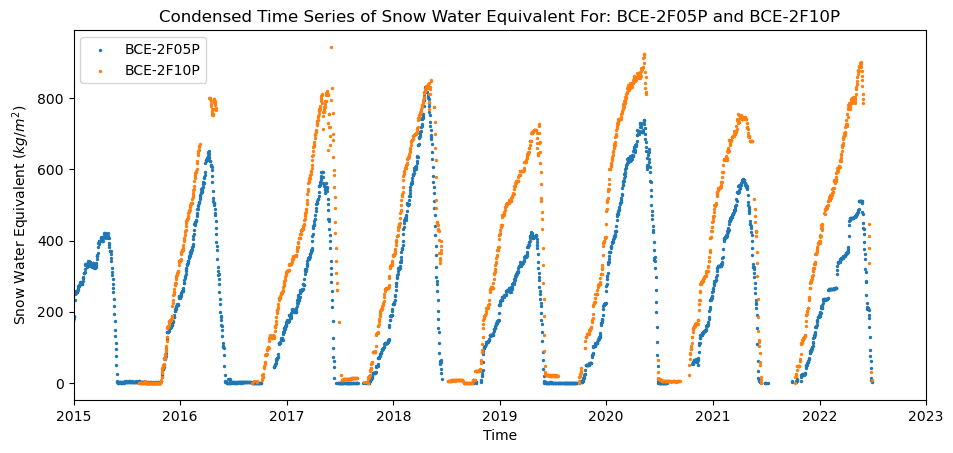

In [15]:
title = 'Condensed Time Series of Snow Water Equivalent For: '+stn2+' and '+stn3
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time2, time3],
                 [snw2, snw3], 
                 [stn2, stn3], 
                 title, xaxis, yaxis, datetime(2015, 1, 1).date(), datetime(2023, 1, 1).date(), True)

From the above time series, it can be noted that the trend between these 2 plots are very similar. Nonetheless, Station BCE-2F10P (in orange) tends to have higher peaks.

<span style="color:red">In the interest of the tutorial length, let's remove the following snow depth plot.</span>

#### Plotting The Snow Depth of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Secondly, we use the createTimeSeries() function to plot the snow depth data for Stations BCE-2G03P, BCE-2F05P and BCE-2F10P.

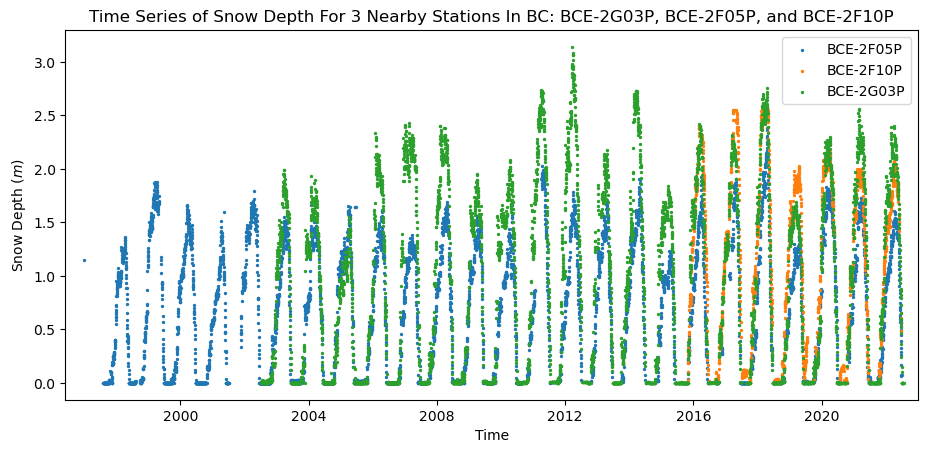

In [16]:
title = 'Time Series of Snow Depth For 3 Nearby Stations In BC: '+maxStn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snow Depth ($m$)'
createTimeSeries([time2, time3, time],
                 [snd2, snd3, snd], 
                 [stn2, stn3, maxStn], 
                 title, xaxis, yaxis, datetime(1996, 6, 1).date(), datetime(2023, 1, 1).date(), True)

<span style="color:red">In the interest of the tutorial length, let's remove the following snow density plot.</span>

#### Plotting The Snowpack Bulk Density of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Thirdly, we use the createTimeSeries() function to plot the snowpack bulk density data for Stations BCE-2G03P, BCE-2F05P and BCE-2F10P.

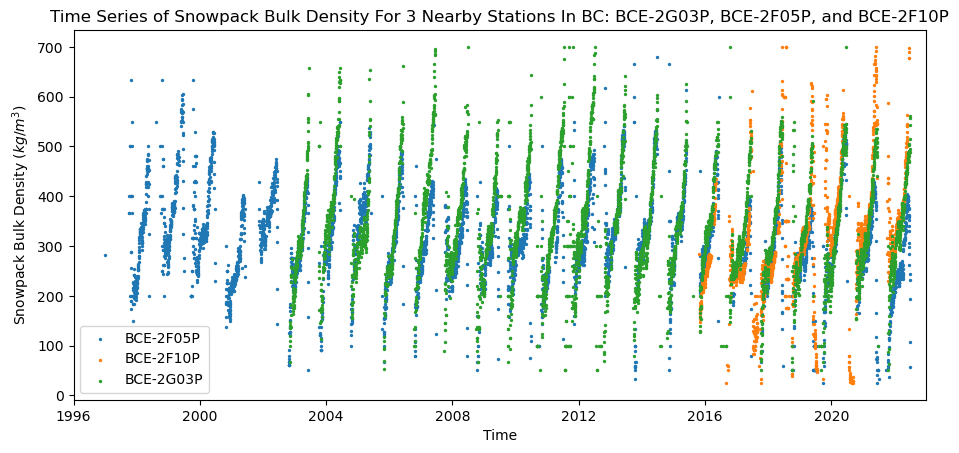

In [17]:
title = 'Time Series of Snowpack Bulk Density For 3 Nearby Stations In BC: '+maxStn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snowpack Bulk Density ($kg/m^3$)'
createTimeSeries([time2, time3, time], 
                 [den2, den3, den], 
                 [stn2, stn3, maxStn],
                 title, xaxis, yaxis, datetime(1996, 1, 1).date(), datetime(2023, 1, 1).date(), True)

<span style="color:red">Having looked at this again, I think we should focus in this next section only on BCE-2G03 and BCE-2G03P. These two stations are at the same location and are therefore directly comparable and I'd like to try to keep the tutorial on the shorter side, so let's remove the code from this section that doesn't just focus on those two stations. We can keep the code somewhere for safe keeping in case we need to reference it in the future.</span>

#### Finding a Station in British Columbia With a Snow Water Equivalent Measurement Code of 0
The 3 stations we have examined so far all have a Snow Water Equivalent measurement code of 2, which means the data is sampled using a snow pillow or a snow scale. We also want to determine if different measurement codes  produce different Snow Water Equivalent trends. As a result, we will find a station with the most entries in British Columbia that has a measurement code of 0, which means that this data is sampled using a multi point manual snow survey.

In [18]:
stn4 = ''
maxStn2 = ''
count4 = 0
maxCount2 = 0
i4 = -1
tempIndex2 = -1
longitude5 = 0
latitude5 = 0
for index, row in df.iterrows():
    if row['source'] == 'British Columbia Environment' and row['type_mes'] == 0:
        if stn4 == '' and count4 == 0:
            stn4 = row['station_id']
            count4 = count4 + 1
        elif row['station_id'] == stn4:
            count4 = count4 + 1
        else:
            if count4 > maxCount2:
                maxCount2 = count4
                maxStn2 = stn4
                i4 = tempIndex2
                longitude5 = row['lon']
                latitude5 = row['lat']

            stn4 = row['station_id']
            count4 = 1
            tempIndex2 = index
print('Station With Measurement Code of 0: '+maxStn2)

Station With Measurement Code of 0: BCE-4C03


#### Introducing Stations BCE-4C03, and BCE-2G03
From the linear search above, we found that Station BCE-4C03 is the station with the most entries in British Columbia that has a measurement code of 0. The official name of Station BCE-4C03 is Dease Lake. It has a latitude of 58.42864 (degrees North) and a longitude of -130.0132 (degrees East). The elevation there is 820 meters. <br> <br>
We will also look at Station 2G03, which is another station in British Columbia with a measurement code of 0. The official name of station BCE-2G03 is Blackwall Peak. It has a latitude of 49.1 (degrees North) and a longitude of -120.76667 (degrees East). The elevation there is 1940 meters. <br> <br>
In this section of the tutorial, we will work with 4 stations: BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10. The former two are stations we just introduced and each have a measurement code of 0. The latter two are stations we have worked with previously and each have a measurement code of 2.

#### Plotting The Geogphical Locations of BCE-2G03P, BCE-4C03, and BCE-2G03
Using our createContourPlot() function again, we will plot these 4 stations on one graph to illustrate where they are located and how close they are to one another.

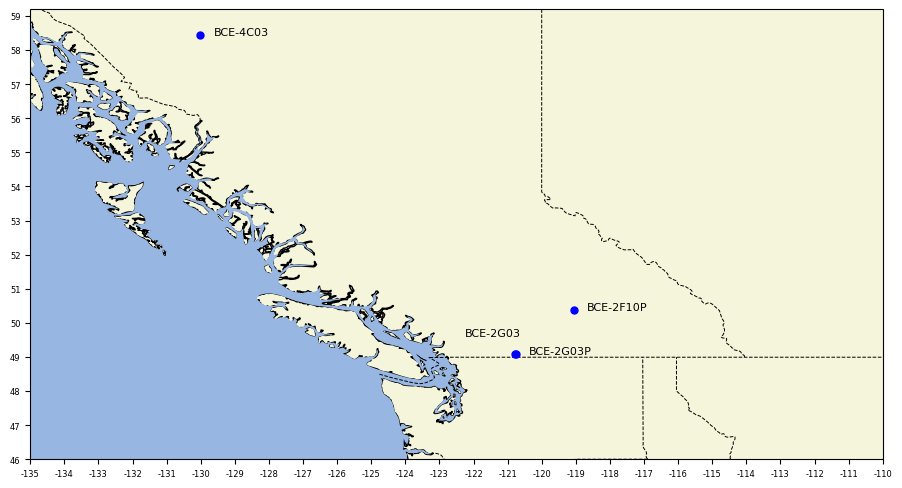

In [19]:
stn4 = 'BCE-4C03'
stn5 = 'BCE-2G03'

#Station BCE-4C03
latitude4 = 58.42864
longitude4 = -130.0132

#Station BCE-2G03
latitude5 = 49.1
longitude5 = -120.76667

def locations():
    return np.array([[longitude, latitude], [longitude3, latitude3], [longitude4, latitude4], [longitude5, latitude5]])
x, y = locations().T
stnIDs = [maxStn, stn3, stn4, stn5]
xLabels = [x[0] + 0.4, x[1] + 0.4, x[2] + 0.4, x[3] - 1.5]
yLabels = [y[0], y[1], y[2], y[3] + 0.5]
createContourPlot(x, y, xLabels, yLabels, stnIDs)


In the above contour plot, we only see 3 blue circle markers because station BCE-2G03P and BCE-2G03 have the exact same longitude and latitude coordinate. 

#### Extracting Data For Stations BCE-2F05P and BCE-2F10P into Separate Lists
In this section of the tutorial, we will compare the data that is found in Stations BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10. However, before this comparison, we first need to interate through the SWE Pandas dataframe to find where the data for Stations BCE-4C03 and BCE-2G03 are located. Then, we will extract the snow water equivalence, snow depth, and snowpack bulk density data for these 2 stations.

In [20]:
#Station BCE-4C03
#Finding where the Station BCE-4C03 data is
stn4 = 'BCE-4C03'
i4 = -1
count4 = 0
for index, row in df.iterrows():
    if row['station_id'] == stn4:
        i2 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == stn4:
        count4 = count4 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin4 = i4
end4 = begin4 + count4 - 1
reducedDf4 = df.loc[begin4:end4]
snw4 = reducedDf4['snw']

time4 = []
for i in reducedDf4['time']:
   time4.append(datetime.strptime(i,'%Y-%m-%d').date())


#Station BCE-2G03
#Finding where the Station BCE-2G03 data is
stn5 = 'BCE-2G03'
i5 = -1
count5 = 0
for index, row in df.iterrows():
    if row['station_id'] == stn5:
        i5 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == stn5:
        count5 = count5 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin5 = i5
end5 = begin5 + count5 - 1
reducedDf5 = df.loc[begin5:end5]
snw5 = reducedDf5['snw']

time5 = []
for i in reducedDf5['time']:
   time5.append(datetime.strptime(i,'%Y-%m-%d').date())


#### Plotting SWE Data For all 4 Stations: BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10
We now call the createTimeSeries() function to plot the SWE data for Station BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10.

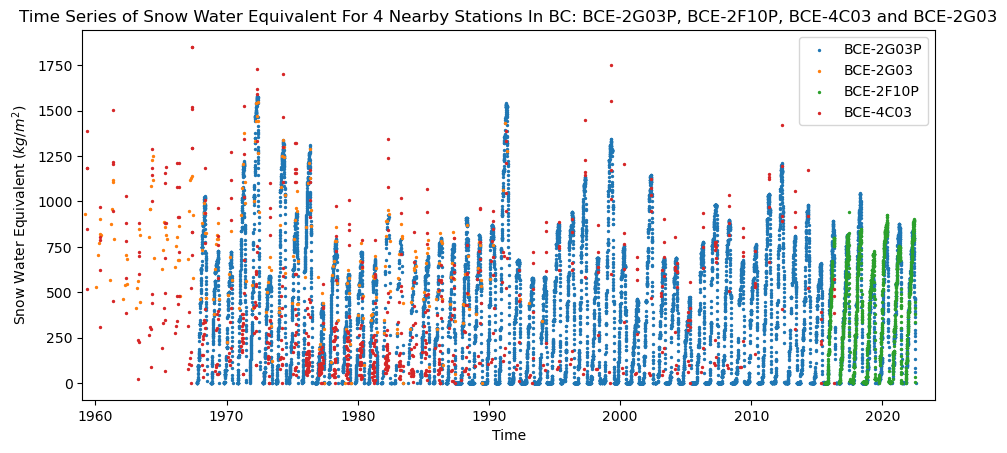

In [28]:
title = 'Time Series of Snow Water Equivalent For 4 Nearby Stations In BC: '+maxStn+', '+stn3+', '+stn4+' and '+stn5
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time, time5, time3, time4], 
                 [snw, snw5, snw3, snw4], 
                 [maxStn, stn5, stn3, stn4], 
                 title, xaxis, yaxis, datetime(1959, 1, 1).date(), datetime(2024, 1, 1).date(), True)

#### Plotting SWE Data For BCE-4C03 and BCE-2G03P

<span style="color:red">Let's keep this plot. This gives us a good idea of the difference in data density and quality from the old sample method vs the newer automatic methods.</span>

In the contour plot where we plotted the locations of these 4 stations, we can see that stations BCE-4C03 and BCE-2G03P are extremely close to each other. As a result, we will take a closer look at how their snow water equivalent data differs.

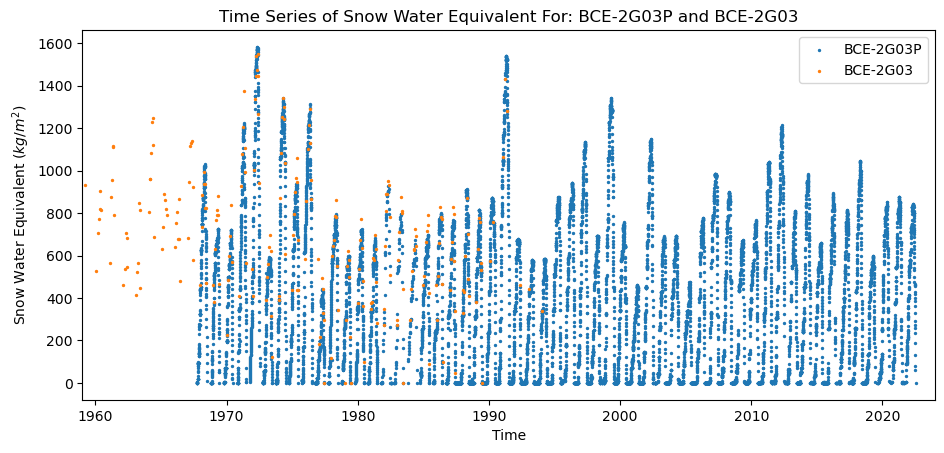

In [29]:
title = 'Time Series of Snow Water Equivalent For: '+maxStn+' and '+stn5
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time, time5], 
                 [snw, snw5], 
                 [maxStn, stn5], 
                 title, xaxis, yaxis, datetime(1959, 1, 1).date(), datetime(2024, 1, 1).date(), True)

From the above contour plot, Station BCE-2G03 (in orange), which has a measurement code of 0, has data that is scattered all over the place and does not really follow any sort of trend. Nonetheless, Station BCE-2G03P (in blue), which has a measurement code of 2, has data that follows some sort of sinusoidal trend.

#### Plotting SWE Data For Station BCE-2G03P But Distinguishing Them Based on Quality Flags
Quality flags provides information on the reliability of data in this dataset. For station BCE-2G03P, most of the data is not flagged, which means that it should be reliable. However, there are flags for some data points which could mean the data is missing (M flag), the data is an estimate (E flag) or the data is even revised (R flag). We will now plot the data for station BCE-2G03P and distinguish the data points by their quality flags.

<span style="color:red">This is good, but let's find the different quality flags using pandas groupby operations instead of iterrows(). Also, rather than printing out the list of all missing dates, let's print a count of the number of missing dates in a given year. We could store this info in a dataframe.</span>

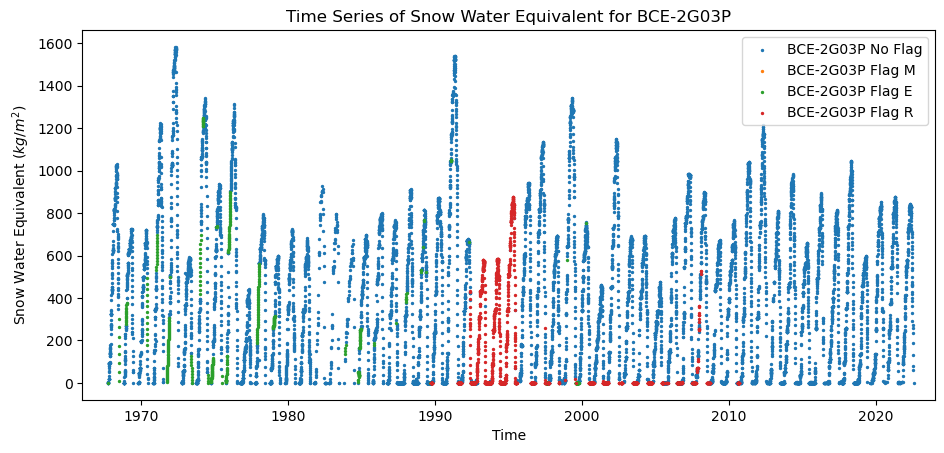

Dates of Missing SWE Data: 
['2002-07-15', '2002-07-16', '2002-07-17', '2002-07-18', '2002-07-19', '2002-07-20', '2002-07-21', '2002-07-22', '2002-07-23', '2002-07-24', '2002-07-25', '2002-07-26', '2002-07-27', '2002-07-28', '2002-07-29', '2002-07-30', '2002-07-31', '2002-08-01', '2002-08-02', '2002-08-03', '2002-08-04', '2002-08-05', '2002-08-06', '2002-08-07', '2002-08-08', '2002-08-09', '2002-08-10', '2002-08-11', '2002-08-12', '2002-08-13', '2002-08-14', '2002-08-15', '2002-08-16', '2002-08-17', '2002-08-18', '2002-08-20', '2002-08-21', '2002-08-22', '2002-08-23', '2002-08-24', '2002-08-25', '2002-08-26', '2002-09-17', '2002-09-18', '2002-09-19', '2002-09-20', '2002-09-22', '2002-09-23', '2002-09-24', '2002-09-25', '2002-09-26', '2002-09-27', '2002-09-28', '2002-09-30', '2002-10-01', '2002-10-02', '2002-10-03', '2002-10-04', '2002-10-05', '2002-10-06', '2002-10-07', '2002-10-08', '2002-10-09', '2002-10-10', '2002-10-11', '2002-10-12', '2002-10-13', '2002-10-14', '2002-10-15', '2002

In [33]:
eFlagTime = []
eFlagSwn = []
rFlagSwn = []
rFlagTime = []
mFlagSwn = []
mFlagTime = []
noFlagTime = []
noFlagSwn = []

for index, row in df.iterrows():
    if row['station_id'] == maxStn:
        if row['data_flag_snw'] == "b'M'":
            mFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            mFlagSwn.append(row['snw'])
        elif row['data_flag_snw'] == "b'E'":
            eFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            eFlagSwn.append(row['snw'])
        elif row['data_flag_snw'] == "b'R'":
            rFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            rFlagSwn.append(row['snw'])
        elif row['data_flag_snw'] == "b''":
            noFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            noFlagSwn.append(row['snw'])

title = 'Time Series of Snow Water Equivalent for '+maxStn
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([noFlagTime, mFlagTime, eFlagTime, rFlagTime], 
                 [noFlagSwn, mFlagSwn, eFlagSwn, rFlagSwn], 
                 [maxStn+" No Flag", maxStn+" Flag M", maxStn+" Flag E", maxStn+" Flag R"], 
                 title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1).date(), True)

missingData = []
for index, row in df.iterrows():
    if row['station_id'] == maxStn and row['data_flag_snw'] == "b'M'":
        missingData.append(row['time'])
print("Dates of Missing SWE Data: ")
print(missingData)


From the graph above, we can tell that the estimated data (in green) was present during the 1970s and 1980s. Furthermore, the revised data (in red) was predominately present during the 1990s, but there were also some entries during the 2000s and 2010s. Finally, the missing data is not plotted but the first entry of missing data actually was in 2002.

<span style="color:red">Let's also add one more section. In this section, we'll make a map plot showing all stations in British Columbia where the colour of the station markers tell us about the maximum SWE observed at that location for the year 2023. For example if we use a red-blue colour scale, stations with a smaller max SWE will have reddish markers and stations with a larger max SWE will be blueish. The example here demonstrates how we can acheive this with cartopy: https://stackoverflow.com/questions/66534803/how-to-scatter-plot-values-in-a-range-color-with-cartopy</span>